<a href="https://colab.research.google.com/github/sabuj10h/Machine-learning-practice-/blob/main/Tech_client_survive_prediction_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# 1. IMPORT LIBRARIES


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (accuracy_score,confusion_matrix,classification_report)

In [ ]:

# 2. READ DATA


df = pd.read_csv("/content/Telco Customer Churn.csv")

In [ ]:

# 3. BASIC DATA INSPECTION


print("Shape:", df.shape)

print("\nFirst 5 rows:",df.head())

print("\nData Info:",df.info())

print("\nData Types:",df.dtypes)

print("\nMissing Values:",df.isnull().sum())

print("\nDuplicate Rows:" ,df.duplicated().sum())

print("\nDescriptive Statistics:", df.describe())

Shape: (7043, 21)

First 5 rows:    customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV Str

In [ ]:
object_cols = df.select_dtypes(include="object").columns

for col in object_cols:
    blank_count = df[col].str.strip().eq("").sum()

    if blank_count > 0:
        print(col, "→", blank_count)
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)
print("\nMissing values after TotalCharges conversion:")
print(df.isnull().sum())


Missing values after TotalCharges conversion:
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [ ]:
# ============================================================
# 5. REMOVE CUSTOMER ID
# ============================================================

# customerID is an identifier, not a useful predictive feature
df = df.drop(columns=["customerID"])

In [ ]:
# ============================================================
# 6. TARGET VARIABLE
# ============================================================

# Convert target:
# Yes = 1
# No  = 0

df["Churn"] = df["Churn"].map({"Yes": 1,"No": 0})


In [ ]:
# ============================================================
# 7. BASIC TARGET ANALYSIS
# ============================================================

print("\nChurn Counts:")
print(df["Churn"].value_counts())

print("\nChurn Percentage:")
print(df["Churn"].value_counts(normalize=True) * 100)


Churn Counts:
Churn
0    5174
1    1869
Name: count, dtype: int64

Churn Percentage:
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


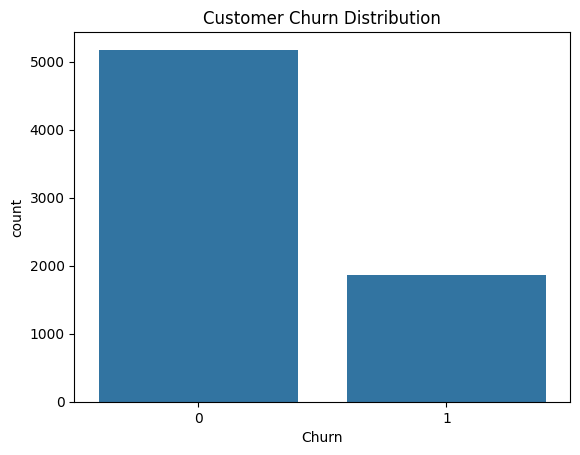

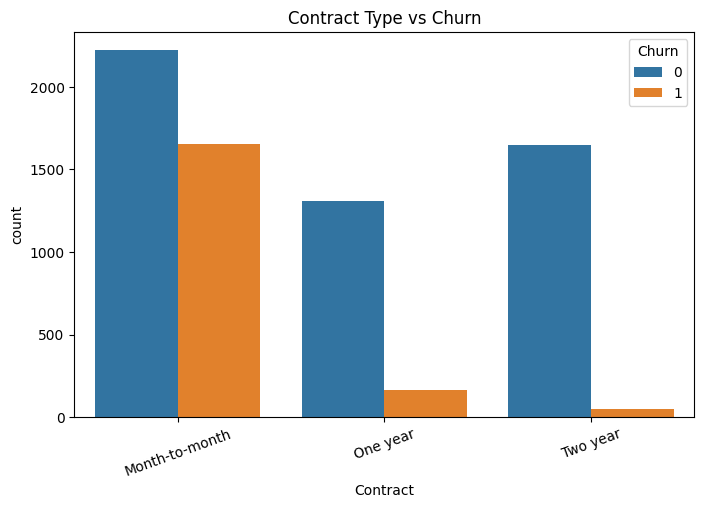

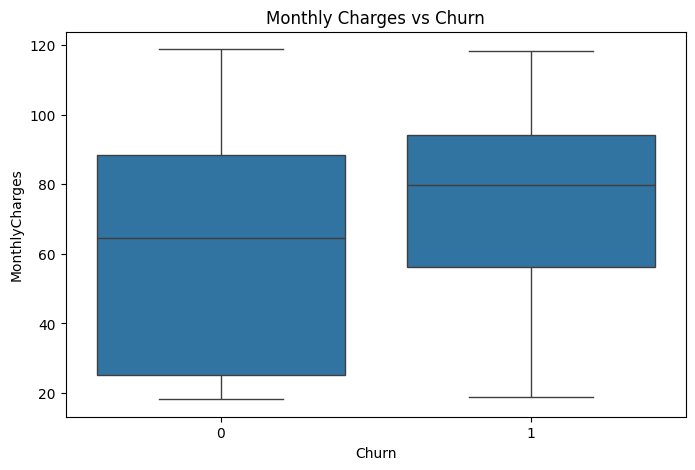

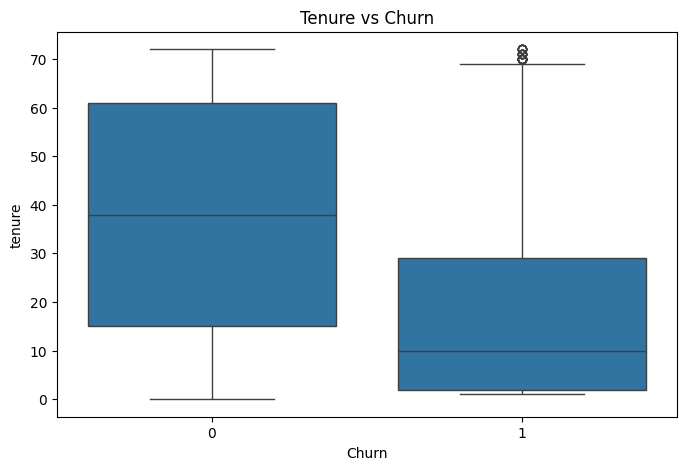

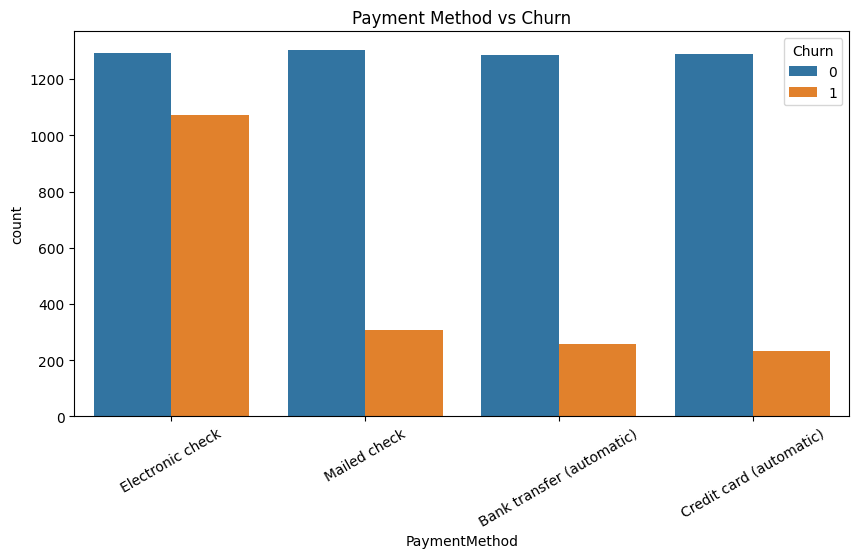

In [ ]:
# ============================================================
# 8. EDA
# ============================================================

# Churn distribution
sns.countplot(data=df, x="Churn")
plt.title("Customer Churn Distribution")
plt.show()


# Contract vs Churn
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Contract Type vs Churn")
plt.xticks(rotation=20)
plt.show()


# Monthly Charges vs Churn
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges vs Churn")
plt.show()


# Tenure vs Churn
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Churn", y="tenure")
plt.title("Tenure vs Churn")
plt.show()


# Payment Method vs Churn
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="PaymentMethod", hue="Churn")
plt.title("Payment Method vs Churn")
plt.xticks(rotation=30)
plt.show()

In [ ]:
# ============================================================
# 9. DEFINE X AND y
# ============================================================

X = df.drop(columns=["Churn"])
y = df["Churn"]

In [ ]:
# ============================================================
# 10. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


print("\nX_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (5634, 19)
X_test shape: (1409, 19)
y_train shape: (5634,)
y_test shape: (1409,)


In [ ]:
print(df["TotalCharges"].dtype)

float64


In [ ]:
# ============================================================
# 11. IDENTIFY NUMERICAL & CATEGORICAL FEATURES
# ============================================================

numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)



Numerical Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical Features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [ ]:
# ============================================================
# 12. PREPROCESSING
# ============================================================

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])


preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [ ]:
# ============================================================
# 13. LOGISTIC REGRESSION
# ============================================================

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])


logistic_model.fit(X_train, y_train)

y_pred_logistic = logistic_model.predict(X_test)


print("\n================ LOGISTIC REGRESSION ================")

print(
    "Accuracy:",
    round(accuracy_score(y_test, y_pred_logistic), 3)
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_logistic))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic))


================ LOGISTIC REGRESSION ================
Accuracy: 0.806

Confusion Matrix:
[[926 109]
 [165 209]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [ ]:
# ============================================================
# 14. DECISION TREE
# ============================================================

dt_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ))
])


dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)


print("\n================ DECISION TREE ================")

print(
    "Accuracy:",
    round(accuracy_score(y_test, y_pred_dt), 3)
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))


================ DECISION TREE ================
Accuracy: 0.798

Confusion Matrix:
[[913 122]
 [162 212]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.88      0.87      1035
           1       0.63      0.57      0.60       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



In [ ]:
# ============================================================
# 15. RANDOM FOREST
# ============================================================

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])


rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)


print("\n================ RANDOM FOREST ================")

print(
    "Accuracy:",
    round(accuracy_score(y_test, y_pred_rf), 3)
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))


================ RANDOM FOREST ================
Accuracy: 0.778

Confusion Matrix:
[[918 117]
 [196 178]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.89      0.85      1035
           1       0.60      0.48      0.53       374

    accuracy                           0.78      1409
   macro avg       0.71      0.68      0.69      1409
weighted avg       0.77      0.78      0.77      1409



In [ ]:
# ============================================================
# 16. CROSS VALIDATION - RANDOM FOREST
# ============================================================

cv_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("\n================ CROSS VALIDATION ================")

print("CV Scores:")
print(np.round(cv_scores, 3))

print(
    "Mean CV Accuracy:",
    round(cv_scores.mean(), 3)
)



================ CROSS VALIDATION ================
CV Scores:
[0.798 0.797 0.785 0.773 0.773]
Mean CV Accuracy: 0.785


In [ ]:
# ============================================================
# 17. GRIDSEARCHCV
# ============================================================

param_grid = {
    "classifier__n_estimators": [50, 100, 200],
    "classifier__max_depth": [3, 5, 7, 10],
    "classifier__max_features": ["sqrt", "log2", None]
}


grid_search = GridSearchCV(
    rf_model,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)


grid_search.fit(X_train, y_train)


print("\n================ GRID SEARCH ================")

print("Best Parameters:")
print(grid_search.best_params_)

print(
    "Best CV Accuracy:",
    round(grid_search.best_score_, 3)
)


================ GRID SEARCH ================
Best Parameters:
{'classifier__max_depth': 7, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 100}
Best CV Accuracy: 0.805


In [ ]:
# ============================================================
# 18. FINAL MODEL
# ============================================================

best_model = grid_search.best_estimator_

y_pred_final = best_model.predict(X_test)


print("\n================ FINAL MODEL ================")

print(
    "Final Test Accuracy:",
    round(accuracy_score(y_test, y_pred_final), 3)
)

print("\nFinal Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_final))

print("\nFinal Classification Report:")
print(classification_report(y_test, y_pred_final))


================ FINAL MODEL ================
Final Test Accuracy: 0.806

Final Confusion Matrix:
[[949  86]
 [187 187]]

Final Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.92      0.87      1035
           1       0.68      0.50      0.58       374

    accuracy                           0.81      1409
   macro avg       0.76      0.71      0.73      1409
weighted avg       0.80      0.81      0.80      1409



In [ ]:
# ============================================================
# 19. FEATURE IMPORTANCE
# ============================================================

final_classifier = best_model.named_steps["classifier"]

importance = final_classifier.feature_importances_

feature_names = (
    best_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)


feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})


feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)


print("\n================ FEATURE IMPORTANCE ================")

print(feature_importance.head(15))


================ FEATURE IMPORTANCE ================
                                     Feature  Importance
1                                num__tenure    0.147717
36              cat__Contract_Month-to-month    0.130378
3                          num__TotalCharges    0.094121
16          cat__InternetService_Fiber optic    0.073885
18                    cat__OnlineSecurity_No    0.072437
43       cat__PaymentMethod_Electronic check    0.058679
2                        num__MonthlyCharges    0.057435
27                       cat__TechSupport_No    0.051969
38                    cat__Contract_Two year    0.044880
21                      cat__OnlineBackup_No    0.020909
20                   cat__OnlineSecurity_Yes    0.019432
15                  cat__InternetService_DSL    0.017395
37                    cat__Contract_One year    0.014828
29                      cat__TechSupport_Yes    0.014242
34  cat__StreamingMovies_No internet service    0.013132


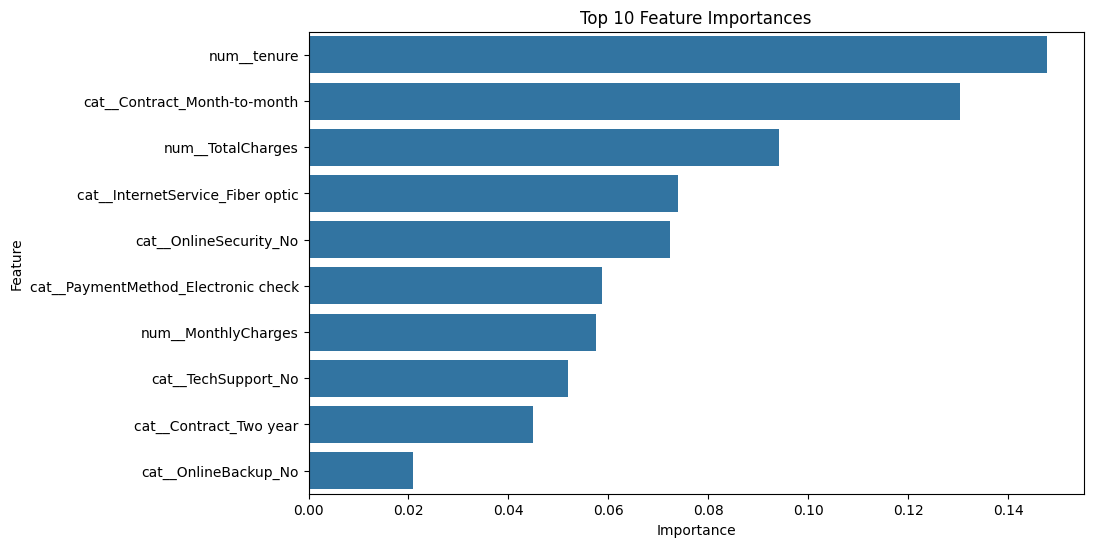

In [ ]:
# ============================================================
# 20. FEATURE IMPORTANCE VISUALIZATION
# ============================================================

top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importances")
plt.show()